# YOLOv8 Nano Training - Google Colab GPU
## Retail Theft Detection

**Features:**
- Downloads dataset directly from Google Drive link
- Saves checkpoints to Google Drive (resume if disconnected)
- GPU accelerated training

---

## 1. Check GPU & Install Packages

In [1]:
# Check GPU availability
!nvidia-smi

Mon Jan 19 09:05:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install required packages
!pip install ultralytics gdown -q
print("Packages installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.4 MB/s eta 0:00:00
Packages installed!


## 2. Mount Google Drive (For Saving Results)

In [4]:
# Mount Google Drive to save checkpoints and results
from google.colab import drive
drive.mount('/content/drive')

# Create output folder in Drive for saving results
import os
DRIVE_OUTPUT = '/content/drive/MyDrive/yolov8_training'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)
print(f"Results will be saved to: {DRIVE_OUTPUT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results will be saved to: /content/drive/MyDrive/yolov8_training


import gdown
import zipfile
import os
import shutil

# Your Google Drive file link
FILE_ID = '1BiUGn_jsilhxCz2WEAZU4K4skix7XfLn'
ZIP_PATH = '/content/phase1_data.zip'
DATASET_PATH = '/content/phase1_data'

# Clean up and start fresh
if os.path.exists(DATASET_PATH):
    shutil.rmtree(DATASET_PATH)

# Create proper folder structure
os.makedirs(f'{DATASET_PATH}/train/images', exist_ok=True)
os.makedirs(f'{DATASET_PATH}/train/labels', exist_ok=True)
os.makedirs(f'{DATASET_PATH}/valid/images', exist_ok=True)
os.makedirs(f'{DATASET_PATH}/valid/labels', exist_ok=True)
os.makedirs(f'{DATASET_PATH}/test/images', exist_ok=True)
os.makedirs(f'{DATASET_PATH}/test/labels', exist_ok=True)

# Download ZIP
print("Downloading dataset...")
gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', ZIP_PATH, quiet=False)

# Extract with proper path handling
print("\nExtracting dataset...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    for member in zip_ref.namelist():
        # Fix Windows backslashes to forward slashes
        fixed_path = member.replace('\\', '/')
        
        # Skip if it's just a directory entry
        if fixed_path.endswith('/'):
            continue
            
        # Determine destination
        if fixed_path.startswith('train/') or fixed_path.startswith('valid/') or fixed_path.startswith('test/'):
            dest_path = f'{DATASET_PATH}/{fixed_path}'
        elif 'train/' in fixed_path:
            # Handle nested paths
            idx = fixed_path.find('train/')
            dest_path = f'{DATASET_PATH}/{fixed_path[idx:]}'
        elif 'valid/' in fixed_path:
            idx = fixed_path.find('valid/')
            dest_path = f'{DATASET_PATH}/{fixed_path[idx:]}'
        elif 'test/' in fixed_path:
            idx = fixed_path.find('test/')
            dest_path = f'{DATASET_PATH}/{fixed_path[idx:]}'
        else:
            # Skip other files
            continue
        
        # Create directory if needed
        os.makedirs(os.path.dirname(dest_path), exist_ok=True)
        
        # Extract file
        with zip_ref.open(member) as source, open(dest_path, 'wb') as target:
            target.write(source.read())

# Remove zip to save space
os.remove(ZIP_PATH)

print("\nDataset extracted successfully!")
print("\n--- Dataset structure ---")
!ls -la {DATASET_PATH}/

In [5]:
import gdown
import zipfile
import os

# Your Google Drive file link
FILE_ID = '1BiUGn_jsilhxCz2WEAZU4K4skix7XfLn'
ZIP_PATH = '/content/phase1_data.zip'
DATASET_PATH = '/content/phase1_data'

# Download if not exists
if not os.path.exists(DATASET_PATH):
    print("Downloading dataset...")
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', ZIP_PATH, quiet=False)

    print("\nExtracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('/content/')

    # Remove zip to save space
    os.remove(ZIP_PATH)
    print("Dataset ready!")
else:
    print("Dataset already exists!")

Downloading...
From (original): https://drive.google.com/uc?id=1BiUGn_jsilhxCz2WEAZU4K4skix7XfLn
From (redirected): https://drive.google.com/uc?id=1BiUGn_jsilhxCz2WEAZU4K4skix7XfLn&confirm=t&uuid=a5a4363a-2d8c-4709-976a-d5f81167f7ec
To: /content/phase1_data.zip
100%|██████████| 397M/397M [00:03<00:00, 125MB/s]



Extracting dataset...
Dataset ready!


In [12]:
# Install gdown
!pip install gdown --quiet

import gdown
import zipfile
import os
import shutil

# Your Drive file ID
FILE_ID = "1BiUGn_jsilhxCz2WEAZU4K4skix7XfLn"

# Construct direct download URL
ZIP_PATH = "/content/phase1_data.zip"
DATASET_PATH = "/content/phase1_data"

# Clean up if exists
if os.path.exists(DATASET_PATH):
    shutil.rmtree(DATASET_PATH)

# Download
print("Downloading dataset from Google Drive...")
gdown.download(f"https://drive.google.com/uc?export=download&id={FILE_ID}", ZIP_PATH, quiet=False)

# Extract
print("\nExtracting dataset...")
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    for member in zip_ref.infolist():
        fixed_path = member.filename.replace("\\", "/")

        # Skip directories
        if member.is_dir():
            continue

        # Determine split subpath
        subpath = None
        for split in ["train/", "valid/", "test/"]:
            if split in fixed_path:
                idx = fixed_path.find(split)
                subpath = fixed_path[idx:]
                break
        if subpath is None:
            continue

        dest_path = os.path.join(DATASET_PATH, subpath)
        os.makedirs(os.path.dirname(dest_path), exist_ok=True)

        with zip_ref.open(member) as source, open(dest_path, "wb") as target:
            target.write(source.read())

# Remove ZIP to save disk
os.remove(ZIP_PATH)

print("\nDataset extracted successfully!")
print("\n--- Sample folders ---")
!ls -R {DATASET_PATH}


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1BiUGn_jsilhxCz2WEAZU4K4skix7XfLn
From (redirected): https://drive.google.com/uc?export=download&id=1BiUGn_jsilhxCz2WEAZU4K4skix7XfLn&confirm=t&uuid=7e519218-6f05-4690-8973-7edd5613ab47
To: /content/phase1_data.zip
100%|██████████| 397M/397M [00:04<00:00, 93.6MB/s]


Streaming output truncated to the last 5000 lines.
fshoplifting_2_25_132_jpg.rf.a84f1ffd9ca3a63f3adac18ac3a551f1.jpg
fshoplifting_2_25_144_jpg.rf.b552afe6f72e3559ddefecf8c46bc673.jpg
fshoplifting_2_25_180_jpg.rf.d23356863fd3efc1ee37c71fd87ca803.jpg
fshoplifting_2_25_270_jpg.rf.91647b30add973a3583485c9281523e7.jpg
fshoplifting_2_25_36_jpg.rf.ff8443b387385b8d5de929a099b3cde4.jpg
fshoplifting_2_25_384_jpg.rf.efd0e7736e4c86604bbdf48ece7decbb.jpg
fshoplifting_2_26_24_jpg.rf.5e25f41ab98add014557214bd485ab54.jpg
fshoplifting_2_26_84_jpg.rf.7b344c11ade4e03ddd8b778c57688981.jpg
fshoplifting_2_27_0_jpg.rf.a30f5a87965424cf23e6441efa62a0bf.jpg
fshoplifting_2_27_1056_jpg.rf.b18ef38b081ccd35973b2babf11f3b63.jpg
fshoplifting_2_27_1068_jpg.rf.a8072faa2f3b6b738911d0d4f964cc56.jpg
fshoplifting_2_27_1128_jpg.rf.ec125c7962ef1eef24a78dd01a4354e1.jpg
fshoplifting_2_27_1152_jpg.rf.685c6d2d90a63d2549c7afc92c631cb6.jpg
fshoplifting_2_27_1242_jpg.rf.c843dd82416698fb3a4ca4a274ec7170.jpg
fshoplifting_2_27_1314_jp

In [13]:
import os

BASE_PATH = "/content/phase1_data"

print("\n========== DATASET STRUCTURE ==========\n")
!ls -lh {BASE_PATH}

print("\n========== IMAGE COUNTS ==========\n")

splits = ["train", "valid", "test"]

for split in splits:
    img_path = f"{BASE_PATH}/{split}/images"
    lbl_path = f"{BASE_PATH}/{split}/labels"

    img_count = len(os.listdir(img_path)) if os.path.exists(img_path) else 0
    lbl_count = len(os.listdir(lbl_path)) if os.path.exists(lbl_path) else 0

    print(f"{split.upper()}:")
    print(f" Images: {img_count}")
    print(f" Labels: {lbl_count}")

    # Basic sanity check
    if img_count != lbl_count:
        print(" ⚠ WARNING: Image/Label count mismatch!")

    print("-" * 40)

print("\n✅ Dataset check complete")



========== DATASET STRUCTURE ==========

total 12K
drwxr-xr-x 4 root root 4.0K Jan 19 09:14 test
drwxr-xr-x 4 root root 4.0K Jan 19 09:14 train
drwxr-xr-x 4 root root 4.0K Jan 19 09:14 valid

========== IMAGE COUNTS ==========

TRAIN:
 Images: 1675
 Labels: 1675
----------------------------------------
VALID:
 Images: 600
 Labels: 600
----------------------------------------
TEST:
 Images: 303
 Labels: 303
----------------------------------------

✅ Dataset check complete


In [14]:
train_imgs = set(os.listdir("/content/phase1_data/train/images"))
val_imgs   = set(os.listdir("/content/phase1_data/valid/images"))
test_imgs  = set(os.listdir("/content/phase1_data/test/images"))

print("Train ∩ Valid duplicates:", len(train_imgs & val_imgs))
print("Train ∩ Test duplicates:", len(train_imgs & test_imgs))
print("Valid ∩ Test duplicates:", len(val_imgs & test_imgs))

if len(train_imgs & val_imgs) == 0 and len(train_imgs & test_imgs) == 0:
    print("\n✅ No data leakage detected")
else:
    print("\n⚠ WARNING: Duplicate frames detected between splits!")


Train ∩ Valid duplicates: 0
Train ∩ Test duplicates: 0
Valid ∩ Test duplicates: 0

✅ No data leakage detected


## 4. Update data.yaml with Colab Paths

In [15]:
# Create updated data.yaml for Colab
data_yaml_content = """path: /content/phase1_data
train: train/images
val: valid/images
test: test/images
nc: 6
names:
- Customer-Bagpack
- Product
- Product-Picked
- Shopping-Cart
- normal
- theft
"""

with open('/content/phase1_data/data.yaml', 'w') as f:
    f.write(data_yaml_content)

print("data.yaml updated!")
!cat /content/phase1_data/data.yaml

data.yaml updated!
path: /content/phase1_data
train: train/images
val: valid/images
test: test/images
nc: 6
names:
- Customer-Bagpack
- Product
- Product-Picked
- Shopping-Cart
- normal
- theft


## 5. Setup Training with Resume Capability

In [16]:
from ultralytics import YOLO
import torch
import shutil

# Verify GPU
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Paths
DATA_YAML = '/content/phase1_data/data.yaml'
PROJECT_DIR = '/content/drive/MyDrive/yolov8_training'  # Save to Drive!
RUN_NAME = 'retail_theft_detection'

# Check if we can resume from previous training
RESUME_PATH = f'{PROJECT_DIR}/{RUN_NAME}/weights/last.pt'
RESUME = os.path.exists(RESUME_PATH)

if RESUME:
    print(f"\n*** Found previous checkpoint! Will RESUME training from: {RESUME_PATH} ***")
else:
    print("\n*** Starting fresh training ***")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.8 GB

*** Starting fresh training ***


## 6. Train YOLOv8 (Auto-saves to Google Drive)

In [17]:
# Load model - either fresh or from checkpoint
if RESUME:
    print("Loading model from checkpoint...")
    model = YOLO(RESUME_PATH)
else:
    print("Loading fresh YOLOv8 Nano model...")
    model = YOLO('yolov8n.pt')

print("Model loaded!")

Loading fresh YOLOv8 Nano model...
Model loaded!


In [18]:
# Train - Results saved directly to Google Drive!
results = model.train(
    data=DATA_YAML,
    epochs=50,              # Total epochs
    batch=16,               # Batch size for GPU
    imgsz=640,
    device=0,               # GPU
    workers=2,
    patience=15,            # Early stopping
    project=PROJECT_DIR,    # Save to Google Drive!
    name=RUN_NAME,
    exist_ok=True,          # Continue in same folder
    resume=RESUME,          # Resume if checkpoint exists
    pretrained=True,
    optimizer='AdamW',
    lr0=0.001,
    verbose=True,
    save=True,              # Save checkpoints
    save_period=5,          # Save every 5 epochs
)

print("\n" + "="*60)
print("TRAINING COMPLETED!")
print(f"Results saved to: {PROJECT_DIR}/{RUN_NAME}")
print("="*60)

Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/phase1_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=retail_theft_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=15, perspective=

## 7. View Training Results

Training Results:


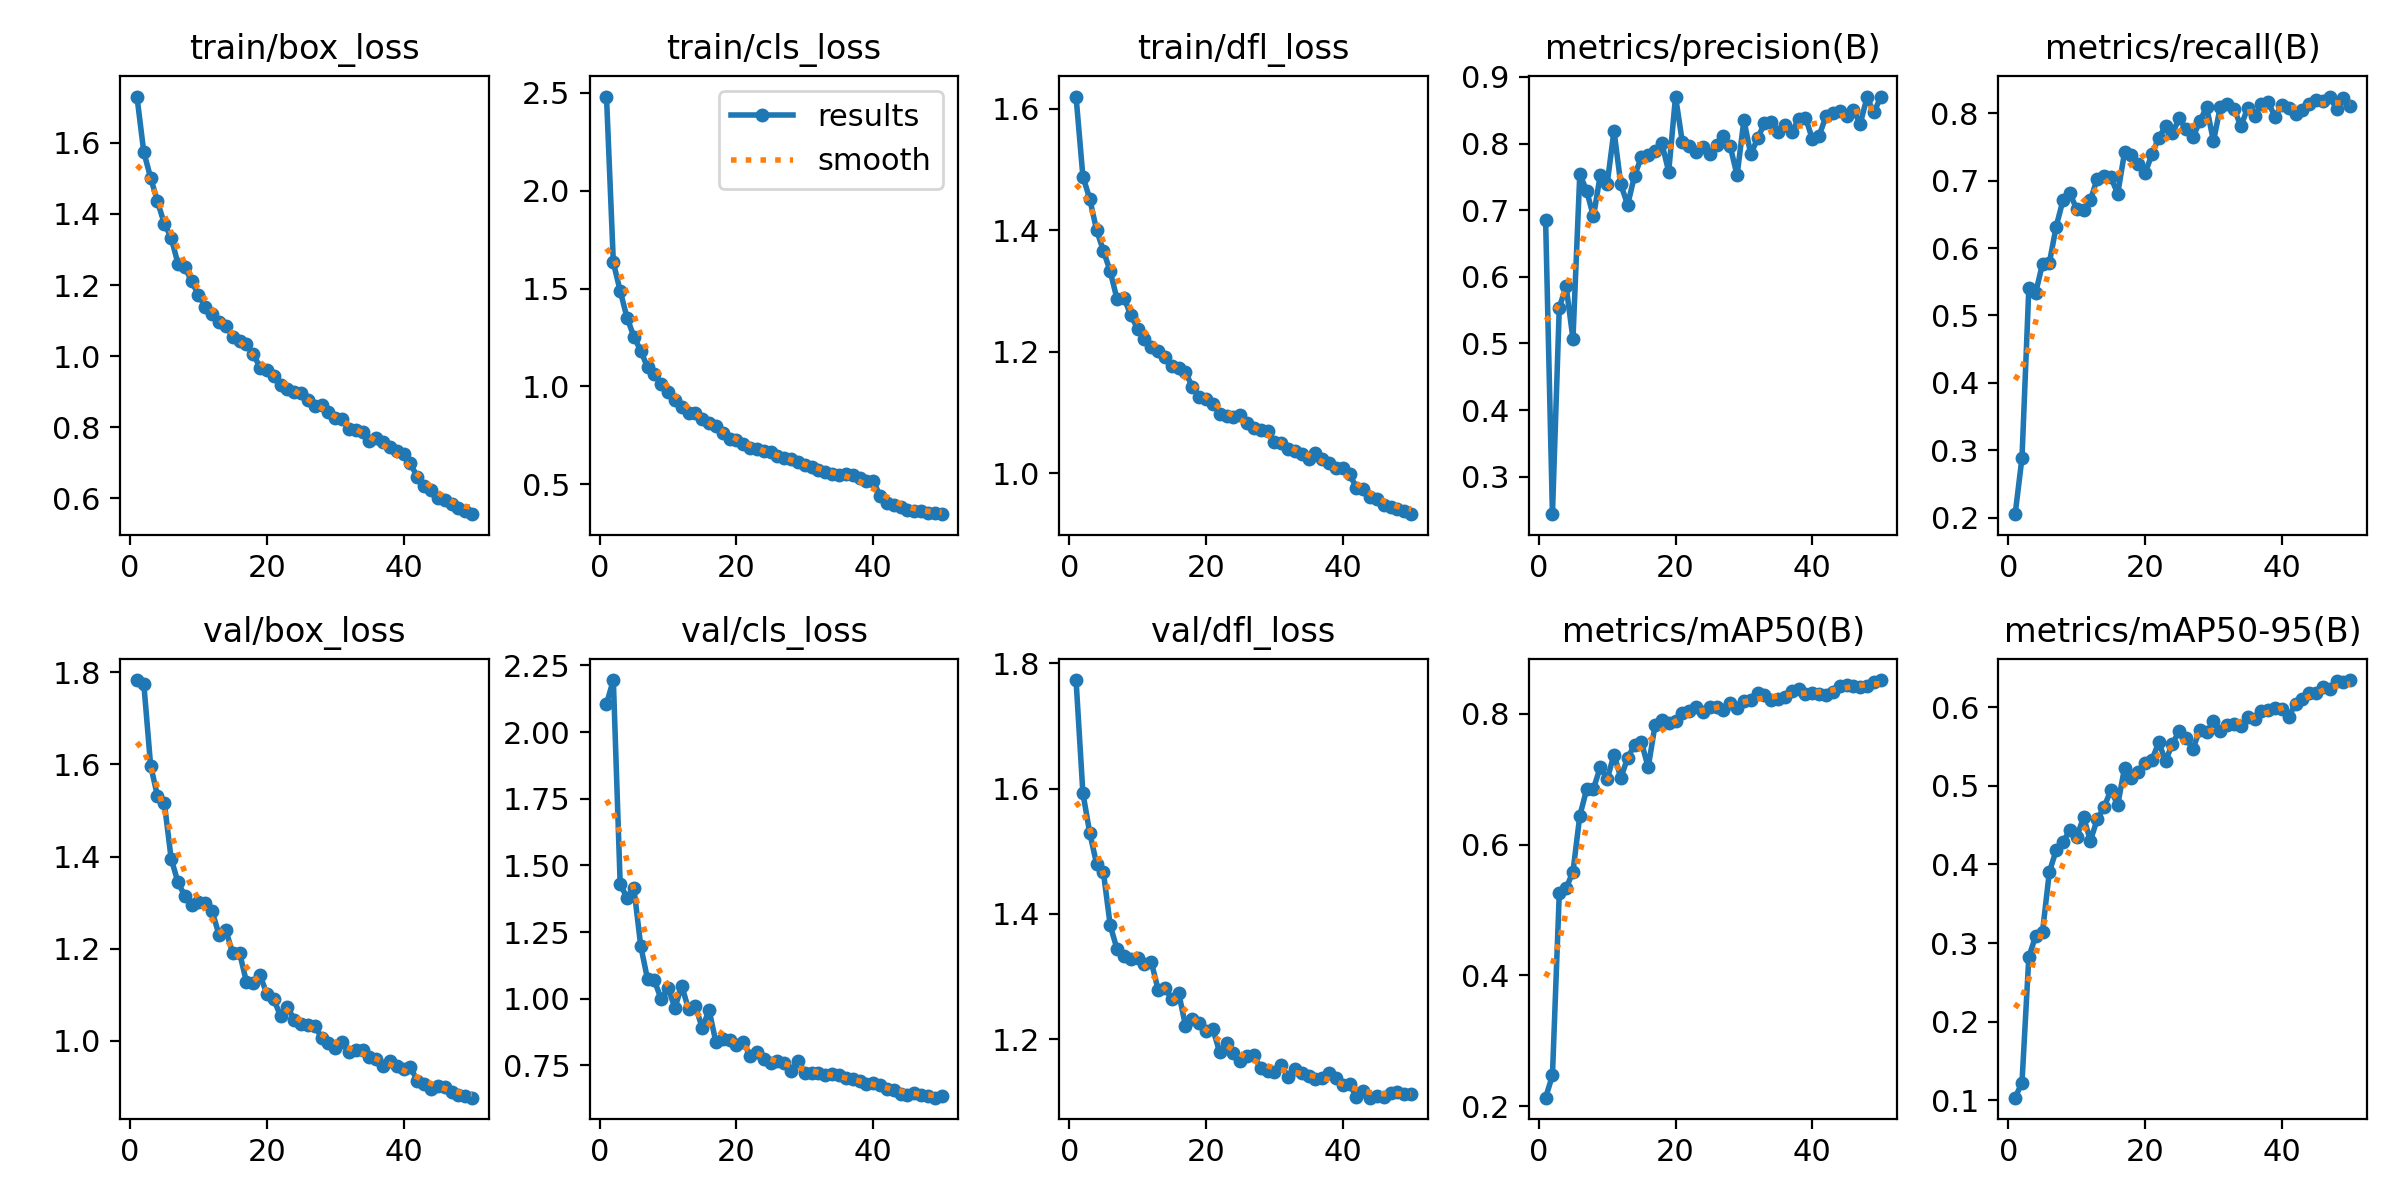


Confusion Matrix:


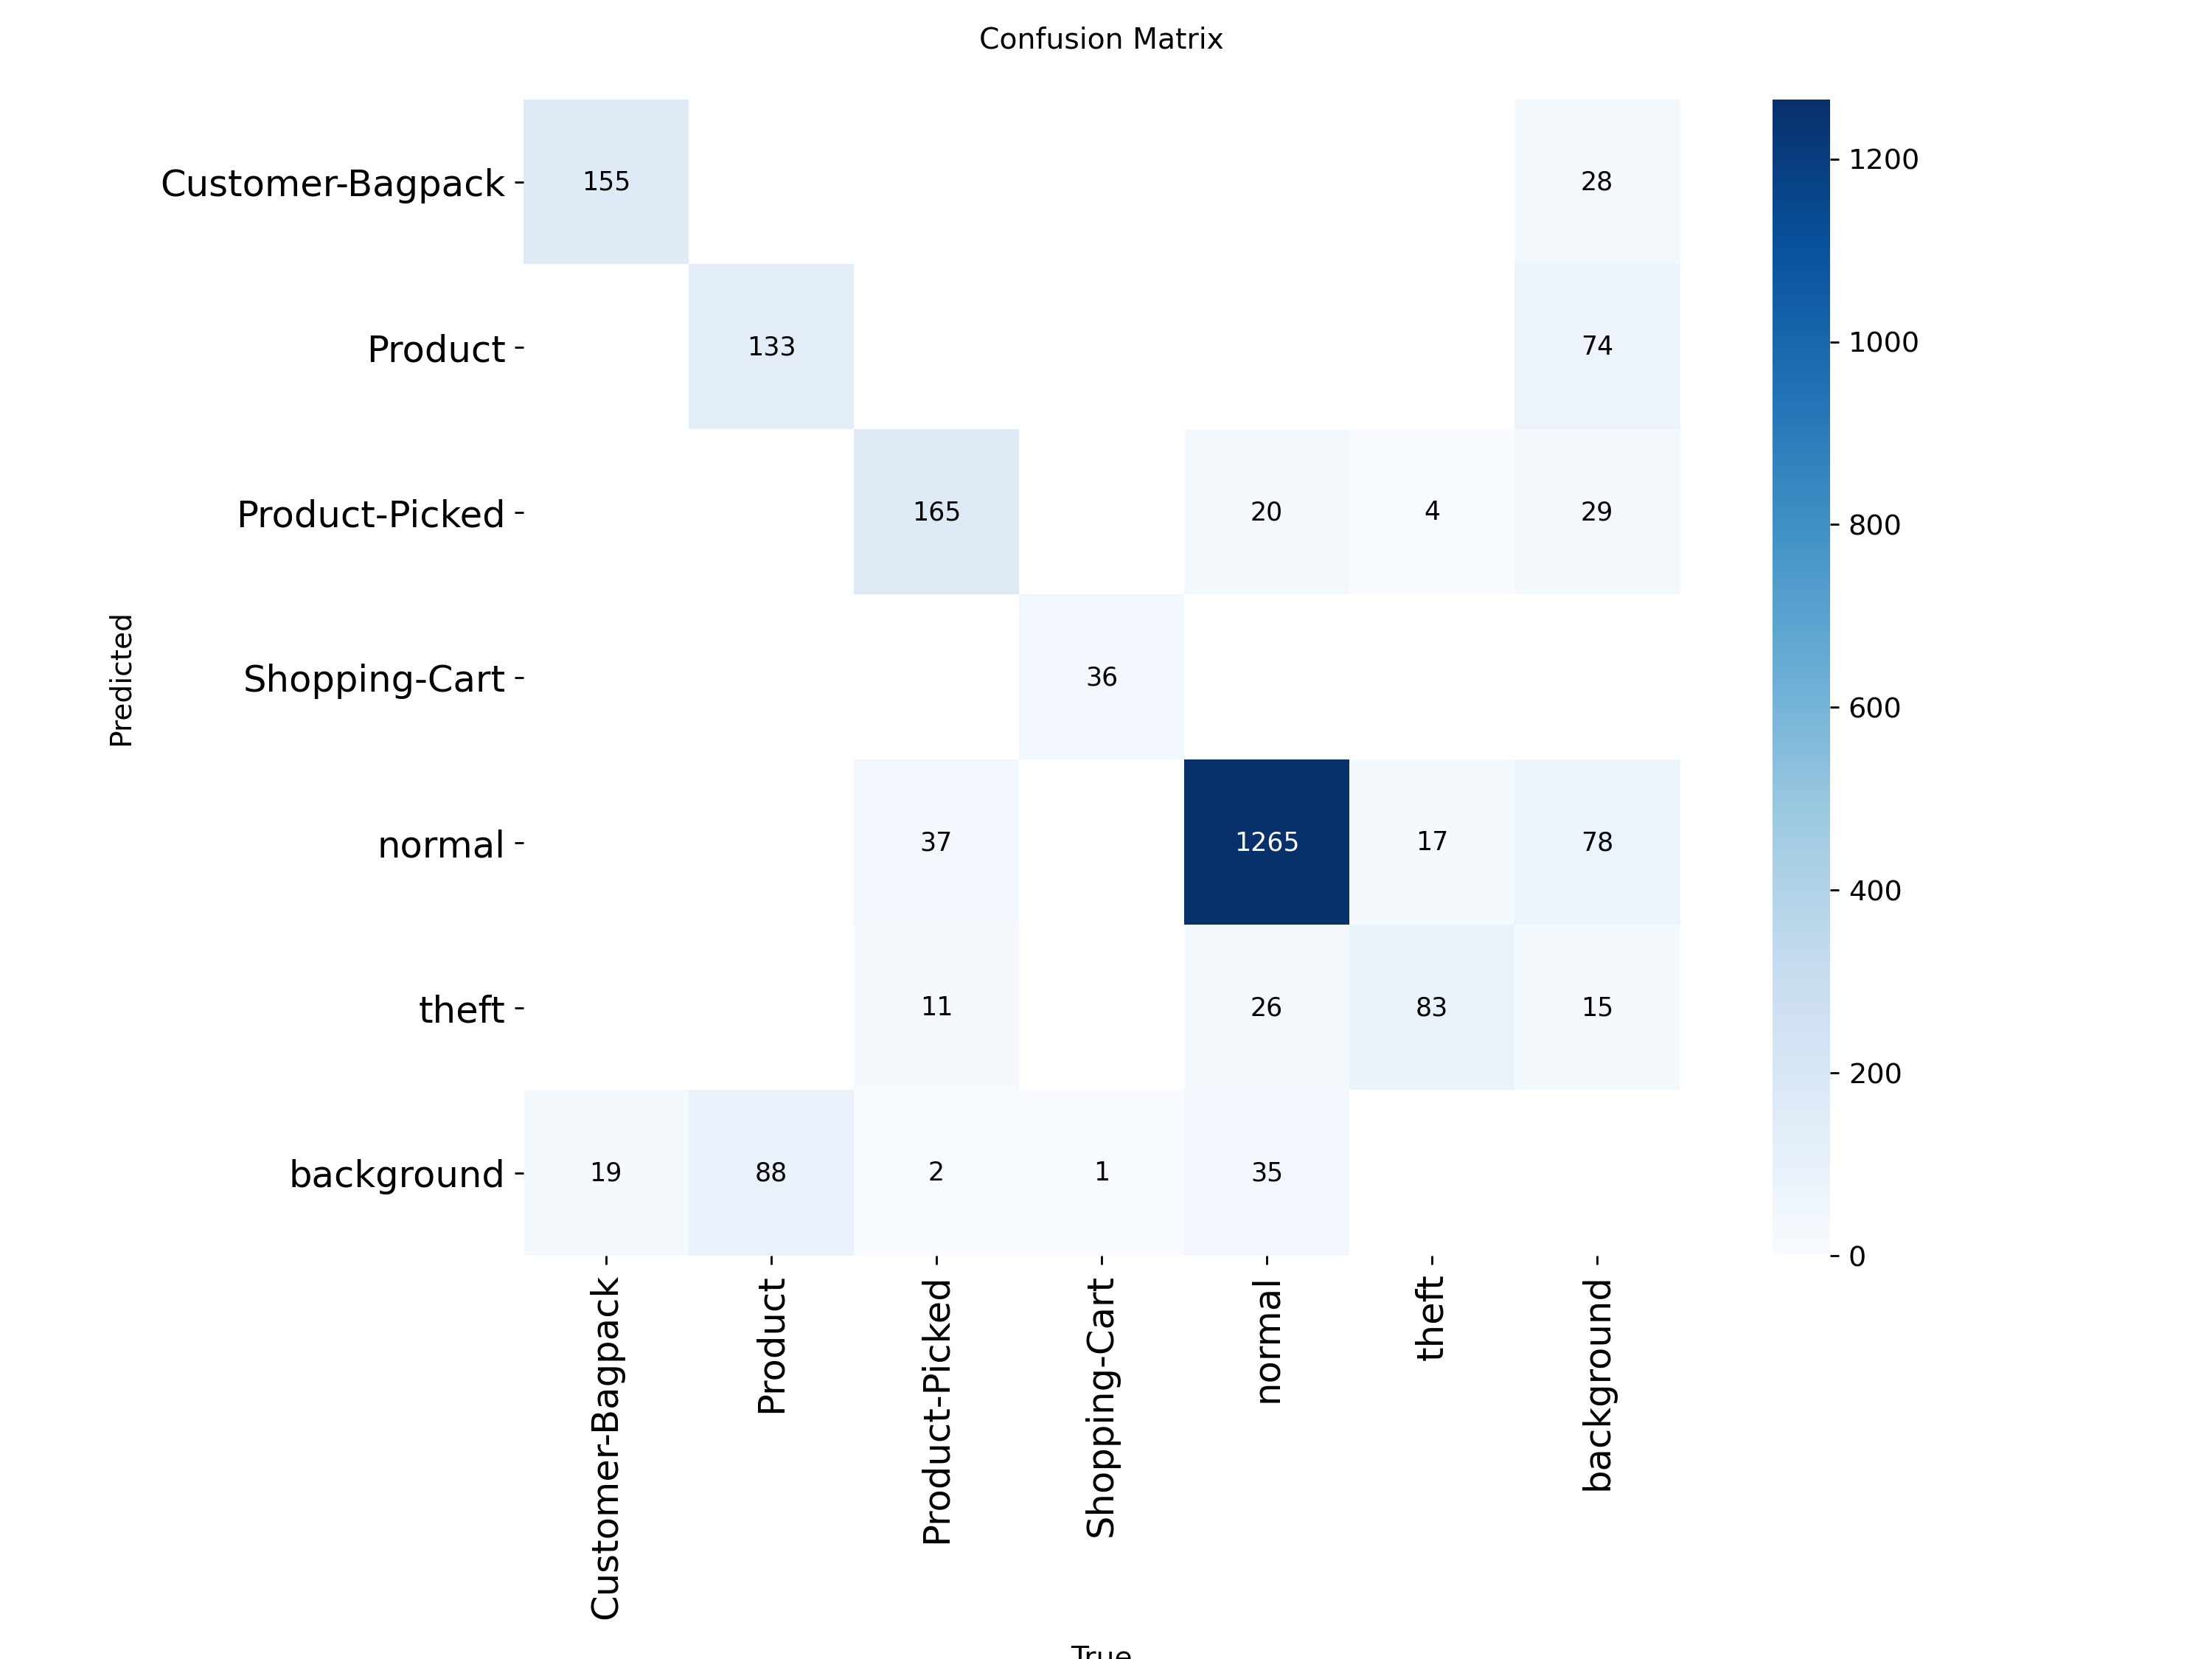

In [19]:
from IPython.display import Image, display
import pandas as pd

results_dir = f'{PROJECT_DIR}/{RUN_NAME}'

# Show results plot
if os.path.exists(f'{results_dir}/results.png'):
    print("Training Results:")
    display(Image(filename=f'{results_dir}/results.png', width=800))

# Show confusion matrix
if os.path.exists(f'{results_dir}/confusion_matrix.png'):
    print("\nConfusion Matrix:")
    display(Image(filename=f'{results_dir}/confusion_matrix.png', width=600))

In [20]:
# Print final metrics
results_csv = f'{results_dir}/results.csv'
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    print("="*60)
    print("FINAL TRAINING METRICS")
    print("="*60)
    print(f"Total Epochs Completed: {len(df)}")

    last = df.iloc[-1]
    for col in df.columns:
        if 'map' in col.lower() or 'precision' in col.lower() or 'recall' in col.lower():
            try:
                print(f"{col}: {last[col]:.4f}")
            except:
                pass

FINAL TRAINING METRICS
Total Epochs Completed: 50
metrics/precision(B): 0.8695
metrics/recall(B): 0.8100
metrics/mAP50(B): 0.8517
metrics/mAP50-95(B): 0.6345


## 8. Validate on Test Set

In [21]:
# Load best model
best_model_path = f'{results_dir}/weights/best.pt'
if os.path.exists(best_model_path):
    best_model = YOLO(best_model_path)
    print(f"Loaded best model from: {best_model_path}")
else:
    print("Best model not found, using last model")
    best_model = YOLO(f'{results_dir}/weights/last.pt')

Loaded best model from: /content/drive/MyDrive/yolov8_training/retail_theft_detection/weights/best.pt


In [22]:
# Validate on test set
val_results = best_model.val(
    data=DATA_YAML,
    split='test',
    device=0,
)

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"mAP@50: {val_results.box.map50:.4f}")
print(f"mAP@50-95: {val_results.box.map:.4f}")

print("\nPer-class AP@50:")
class_names = ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'normal', 'theft']
for i, ap in enumerate(val_results.box.ap50):
    print(f"  {class_names[i]:20}: {ap:.4f}")

Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1874.2±1102.8 MB/s, size: 166.8 KB)
val: Scanning /content/phase1_data/test/labels... 303 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 303/303 1.8Kit/s 0.2s
val: New cache created: /content/phase1_data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.4it/s 4.3s
                   all        303        974      0.786      0.802      0.811      0.596
      Customer-Bagpack         53         63      0.772       0.86      0.899      0.506
               Product         87         89       0.69      0.551       0.57      0.261
        Product-Picked         90         94       0.78      0.777      0.806      0.664
         Shopping-Cart         22         22      0.887      0.909      0.894  

## 9. Test Inference

In [23]:
import glob

# Run inference on test images
test_images = glob.glob('/content/phase1_data/test/images/*.jpg')[:5]

results = best_model.predict(
    source=test_images,
    device=0,
    conf=0.25,
    save=True,
    project=f'{PROJECT_DIR}',
    name='predictions',
    exist_ok=True
)

print(f"Predictions saved to: {PROJECT_DIR}/predictions/")


0: 640x640 1 Product, 1 Product-Picked, 4 normals, 7.6ms
1: 640x640 1 Customer-Bagpack, 1 normal, 7.6ms
2: 640x640 1 Customer-Bagpack, 1 Product-Picked, 4 normals, 7.6ms
3: 640x640 1 Customer-Bagpack, 1 theft, 7.6ms
4: 640x640 1 Product, 1 Product-Picked, 7.6ms
Speed: 2.2ms preprocess, 7.6ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/yolov8_training/predictions
Predictions saved to: /content/drive/MyDrive/yolov8_training/predictions/



fshoplifting_2_24_3078_jpg.rf.7579d9c38782e96f30b9c2c9ee4bcce6.jpg


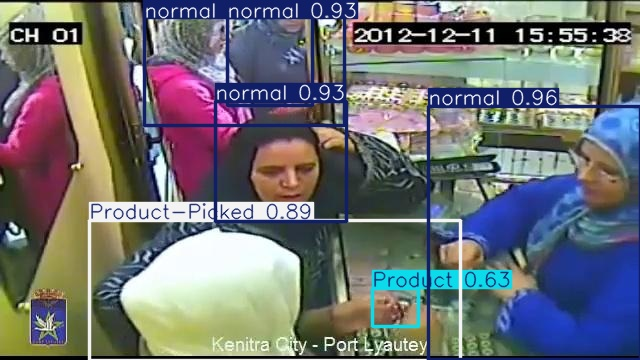


fshoplifting_2_20_1464_jpg.rf.29ddb35aa90492bcefbfc2302522333a.jpg


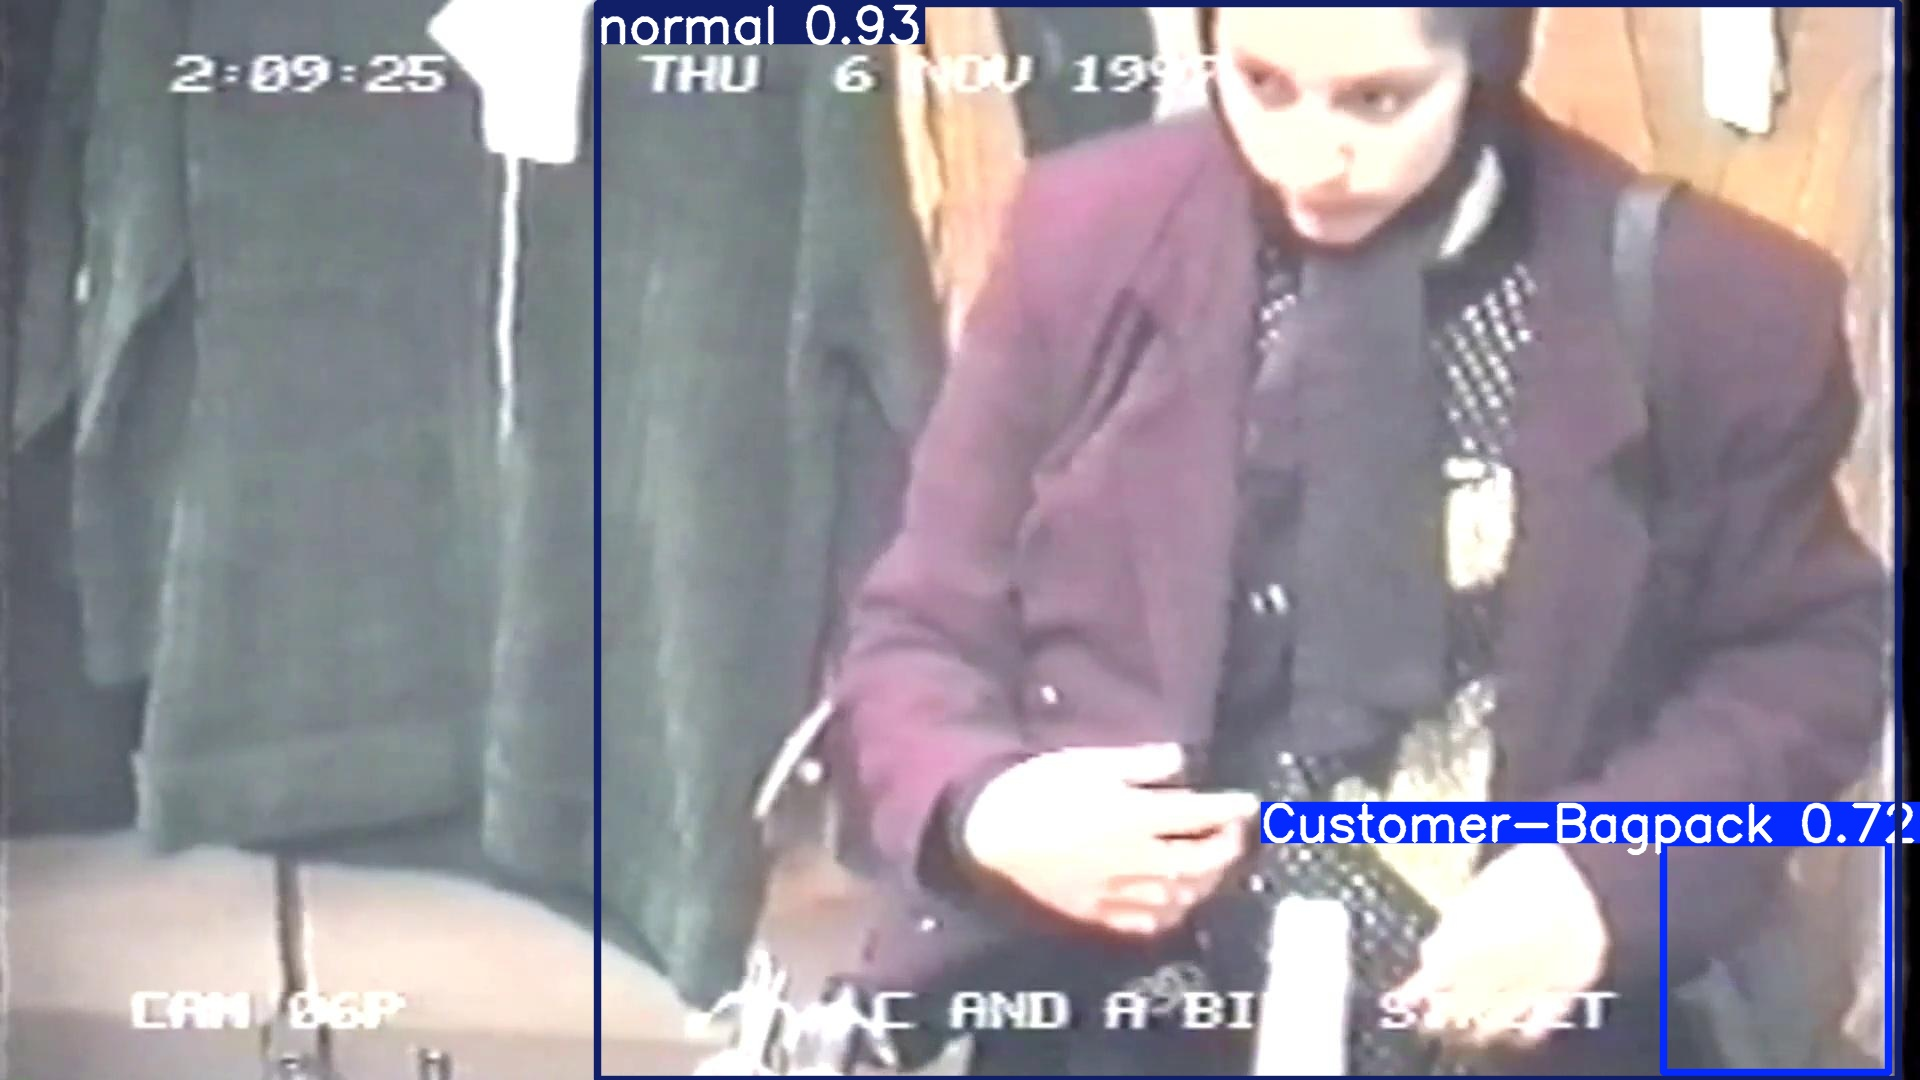


fshoplifting_2_11_606_jpg.rf.59d501d30b9eaf8a85ab45d0c3ccf8c5.jpg


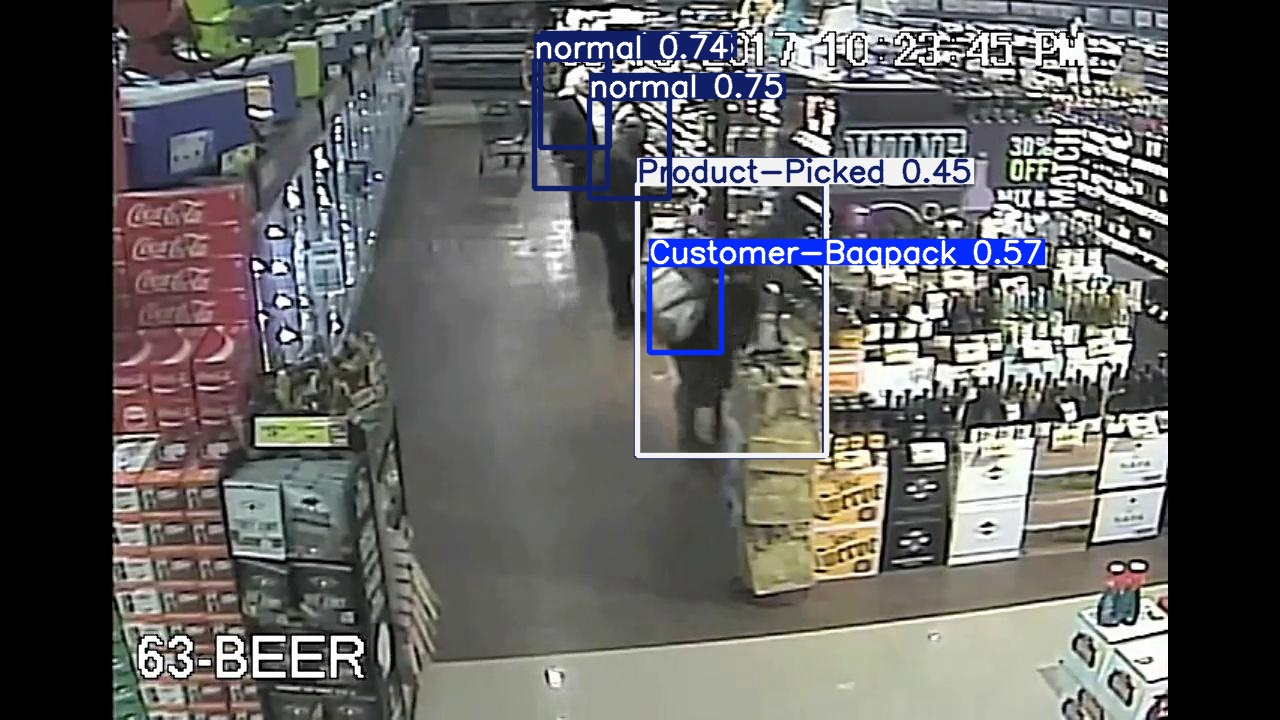


fshoplifting_2_26_24_jpg.rf.5e25f41ab98add014557214bd485ab54.jpg


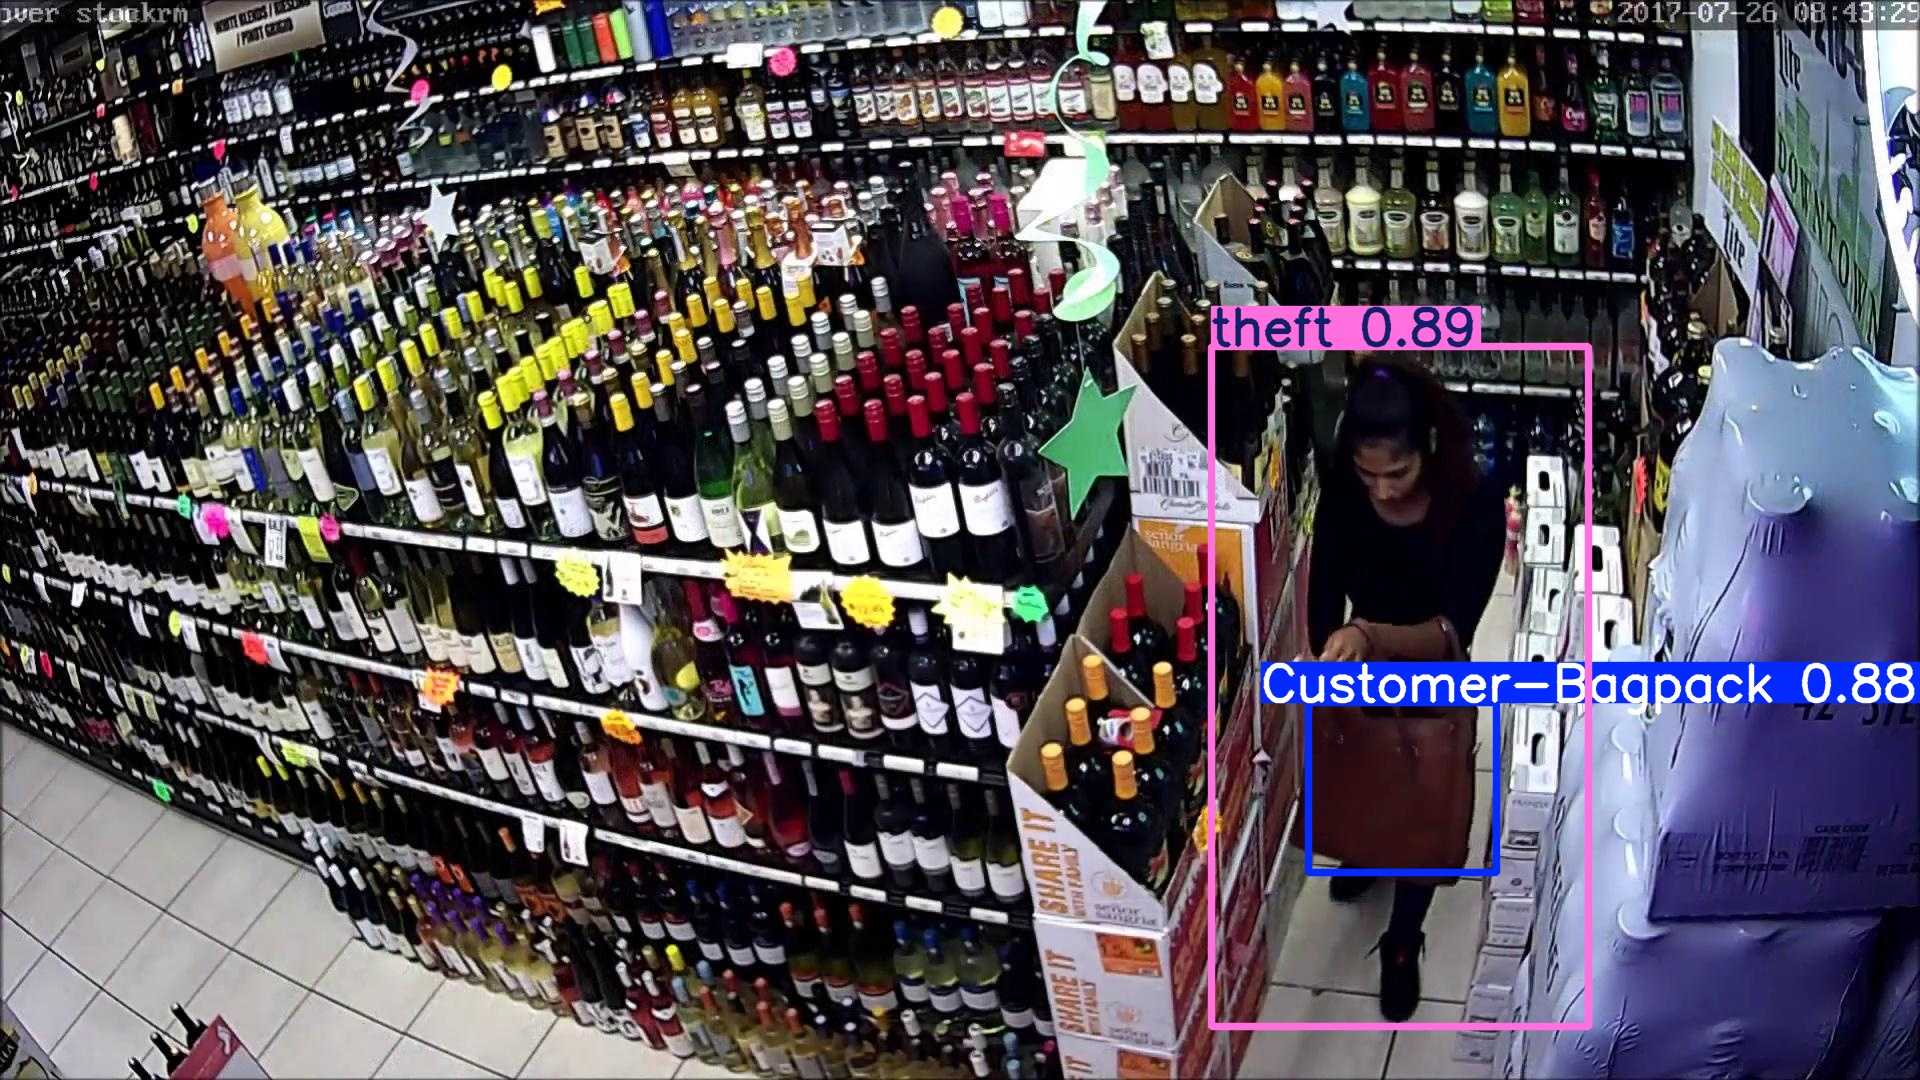

In [24]:
# Display predictions
pred_images = glob.glob(f'{PROJECT_DIR}/predictions/*.jpg')[:4]

for img_path in pred_images:
    print(f"\n{os.path.basename(img_path)}")
    display(Image(filename=img_path, width=500))

## 10. Download Model

In [25]:
# Your model is already saved to Google Drive!
print("Your trained model is saved at:")
print(f"  Google Drive: {PROJECT_DIR}/{RUN_NAME}/weights/best.pt")
print(f"  Google Drive: {PROJECT_DIR}/{RUN_NAME}/weights/last.pt")

print("\nAll files in your training folder:")
!ls -la {PROJECT_DIR}/{RUN_NAME}/

Your trained model is saved at:
  Google Drive: /content/drive/MyDrive/yolov8_training/retail_theft_detection/weights/best.pt
  Google Drive: /content/drive/MyDrive/yolov8_training/retail_theft_detection/weights/last.pt

All files in your training folder:
total 8782
-rw------- 1 root root   1647 Jan 19 09:17 args.yaml
-rw------- 1 root root 264884 Jan 19 09:50 BoxF1_curve.png
-rw------- 1 root root 219367 Jan 19 09:50 BoxP_curve.png
-rw------- 1 root root 207497 Jan 19 09:50 BoxPR_curve.png
-rw------- 1 root root 242571 Jan 19 09:50 BoxR_curve.png
-rw------- 1 root root 214669 Jan 19 09:50 confusion_matrix_normalized.png
-rw------- 1 root root 200950 Jan 19 09:50 confusion_matrix.png
-rw------- 1 root root 112610 Jan 19 09:18 labels.jpg
-rw------- 1 root root   6155 Jan 19 09:50 results.csv
-rw------- 1 root root 267503 Jan 19 09:50 results.png
-rw------- 1 root root 730102 Jan 19 09:18 train_batch0.jpg
-rw------- 1 root root 701770 Jan 19 09:18 train_batch1.jpg
-rw------- 1 root root 

In [26]:
# Download to your computer (optional)
from google.colab import files
files.download(f'{results_dir}/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## How to Resume Training (If Disconnected)

If Colab disconnects or GPU session ends:

1. **Reconnect to Colab** and get a new GPU
2. **Run all cells from the beginning**
3. The notebook will **automatically detect** the checkpoint in Google Drive
4. Training will **resume from where it stopped**

Your progress is safe because:
- Checkpoints saved to Google Drive every 5 epochs
- `last.pt` always contains the latest weights
- `best.pt` contains the best performing weights

---

## To Use Model Locally

```python
from ultralytics import YOLO

# Load your trained model
model = YOLO('best.pt')

# Run inference
results = model.predict('image.jpg', conf=0.25)
results[0].show()
```